# Amazon Last-Mile Data Quality Audit

Source: 2021 Amazon Last Mile Routing Research Challenge training data.

## tl;dr

- The training core contains 6,112 routes from 17 stations between 2018-07-19 and 2018-08-26.
- Route IDs are unique; every route has one station, a complete observed sequence, and no missing drop-off zone ID.
- A station-aware chronological split yields 4,270 train, 916 validation, and 926 test routes.
- The median route contains 151 stops; algorithm runtime must be evaluated at this operational scale.
- Only 102 routes are labelled Low quality, so quality-subgroup findings must carry uncertainty. No model-performance claim is made here.

## Context & Methods

The grain is one historical route. We verify IDs, station-stop integrity, observed-sequence coverage, zone completeness, labels, temporal coverage, and chronological station-aware splits.

### Key Assumptions

- Each route contains exactly one Station stop.
- The observed sequence contains exactly the route stop identifiers.
- Route quality is descriptive, never a predictive feature.
- Obfuscated coordinates are not reverse-geocoded.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from lastmile.audit import profile_routes
from lastmile.data import load_routes
from lastmile.splits import chronological_station_split

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
DATA = ROOT / 'data' / 'raw' / 'training'
ARTIFACTS = ROOT / 'artifacts' / 'data_audit'
ARTIFACTS.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## Data

### 1. Load and validate route records

In [2]:
routes = load_routes(DATA / 'route_data.json', DATA / 'actual_sequences.json')
split = chronological_station_split(routes)
profile = profile_routes(routes, split)
(ARTIFACTS / 'route_profile.json').write_text(
    json.dumps(profile, indent=2, sort_keys=True), encoding='utf-8'
)
print(json.dumps(profile, indent=2, sort_keys=True))

{
  "date_max": "2018-08-26",
  "date_min": "2018-07-19",
  "duplicate_route_id_count": 0,
  "invalid_station_count": 0,
  "missing_dropoff_zone_count": 0,
  "observed_sequence_coverage": 1.0,
  "route_count": 6112,
  "route_score_counts": {
    "High": 2718,
    "Low": 102,
    "Medium": 3292
  },
  "sequence_stop_mismatch_count": 0,
  "split_route_counts": {
    "test": 926,
    "train": 4270,
    "validation": 916
  },
  "split_station_counts": {
    "test": 17,
    "train": 17,
    "validation": 17
  },
  "station_count": 17,
  "station_route_counts": {
    "DAU1": 214,
    "DBO1": 60,
    "DBO2": 296,
    "DBO3": 573,
    "DCH1": 196,
    "DCH2": 154,
    "DCH3": 271,
    "DCH4": 381,
    "DLA3": 254,
    "DLA4": 197,
    "DLA5": 155,
    "DLA7": 1133,
    "DLA8": 448,
    "DLA9": 701,
    "DSE2": 125,
    "DSE4": 446,
    "DSE5": 508
  },
  "stops_per_route": {
    "maximum": 238,
    "median": 151.0,
    "minimum": 33
  }
}


### 2. Build a bounded route-level table

In [3]:
route_frame = pd.DataFrame({
    'route_id': [route.route_id for route in routes],
    'station_code': [route.station_code for route in routes],
    'date': [route.route_date for route in routes],
    'route_score': [route.route_score for route in routes],
    'stop_count': [len(route.stops) for route in routes],
})
route_frame.head()

,route_id,station_code,date,route_score,stop_count
0,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,DLA3,2018-07-27,High,119
1,RouteID_0016bc70-cb8d-48b0-aa55-8ee50bdcdb59,DSE4,2018-07-28,High,106
2,RouteID_001948e9-4675-486d-9ec5-912fd8e0770f,DSE5,2018-08-18,High,128
3,RouteID_001b4ee3-c4f2-467f-932b-c85524d1021f,DLA9,2018-08-15,High,142
4,RouteID_0021a2aa-780f-460d-b09a-f301709e2523,DLA7,2018-08-05,High,155


## Results

### 3. Route volume by station

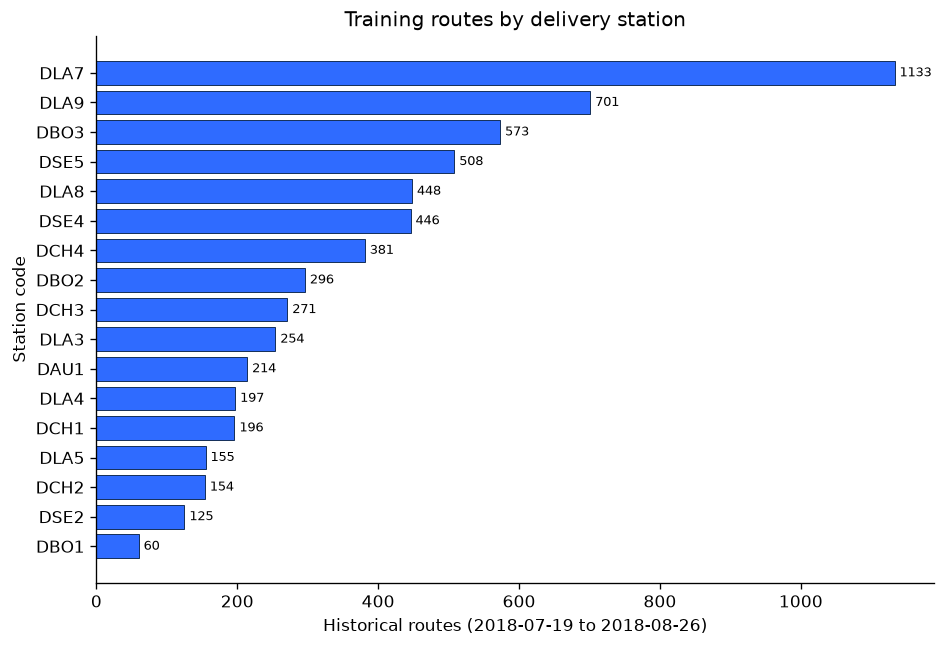

In [4]:
station_counts = route_frame['station_code'].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(station_counts.index, station_counts.values, color='#2F6BFF', edgecolor='#17325C', linewidth=0.6)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title('Training routes by delivery station')
ax.set_xlabel('Historical routes (2018-07-19 to 2018-08-26)')
ax.set_ylabel('Station code')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(ARTIFACTS / 'routes_by_station.png', bbox_inches='tight')
plt.show()

### 4. Operational route-size distribution

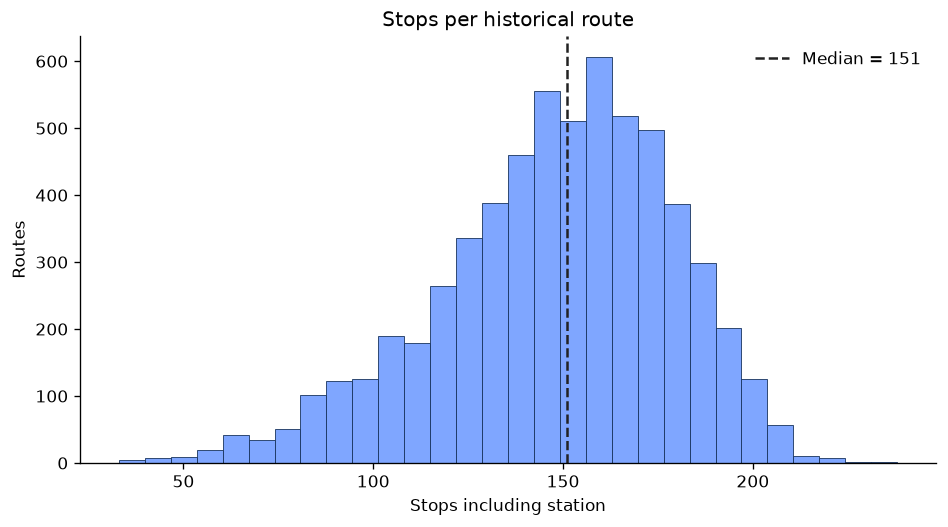

In [5]:
median_stops = route_frame['stop_count'].median()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(route_frame['stop_count'], bins=30, color='#7FA6FF', edgecolor='#17325C', linewidth=0.5)
ax.axvline(median_stops, color='#222222', linestyle='--', linewidth=1.5, label=f'Median = {median_stops:.0f}')
ax.set_title('Stops per historical route')
ax.set_xlabel('Stops including station')
ax.set_ylabel('Routes')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(ARTIFACTS / 'stops_per_route.png', bbox_inches='tight')
plt.show()

### 5. Split and quality summary

In [6]:
quality_summary = pd.DataFrame({
    'check': ['Duplicate route IDs', 'Invalid station count', 'Sequence/stop mismatches', 'Missing drop-off zones', 'Observed-sequence coverage'],
    'value': [profile['duplicate_route_id_count'], profile['invalid_station_count'], profile['sequence_stop_mismatch_count'], profile['missing_dropoff_zone_count'], profile['observed_sequence_coverage']]
})
display(quality_summary)
display(pd.Series(profile['split_route_counts'], name='routes').to_frame())

,check,value
0,Duplicate route IDs,0.0
1,Invalid station count,0.0
2,Sequence/stop mismatches,0.0
3,Missing drop-off zones,0.0
4,Observed-sequence coverage,1.0


,routes
train,4270
validation,916
test,926


## Takeaways

- Use the executed outputs above as controlling evidence.
- Low-quality routes are rare, so subgroup uncertainty must be shown.
- Median route size determines the runtime budget for local search.
- Travel-time and package files remain required for final experiments.